

![Logo ITQ](img/imagen1.png)

**Nombre:** Alexis Arcos
<br>
**Fecha:** 08/04/2026

![Logo Python](img/imagen2.png)

## Examen Practico - Segundo Parcial

#### 0) Cargar una de las imágenes histológicas

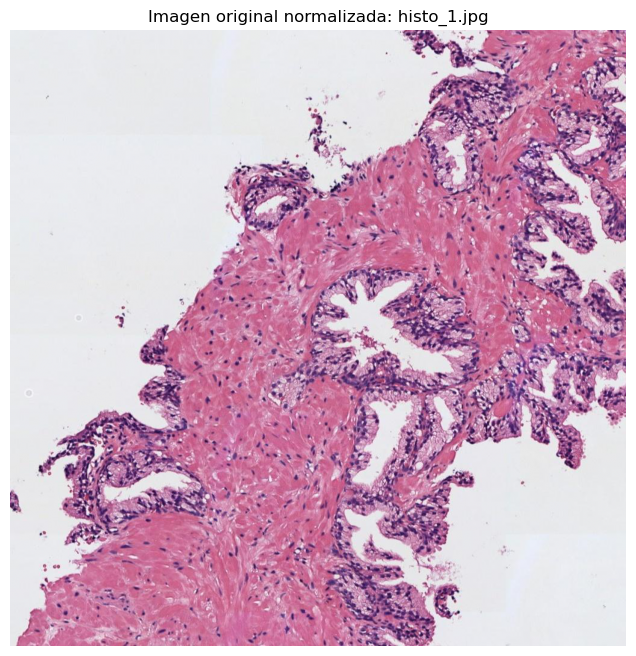

Valor mínimo del píxel: 0.0
Valor máximo del píxel: 1.0


In [11]:
import skimage.io as io
import matplotlib.pyplot as plt
from skimage import img_as_float

# 1. Leemos la imagen con el nombre histo_1
nombre_imagen = 'histo_1.jpg' 
img = io.imread(nombre_imagen)

# 2. Normalizamos la imagen para que los píxeles estén en el rango [0, 1]
# img_as_float convierte automáticamente los valores (que van de 0 a 255) en decimales entre 0 y 1
img_norm = img_as_float(img)

# Si no quisiesemos hacer eso, también podemos hacer img_norm = img / 255.0

# 3. mostramos la imagen
plt.figure(figsize=(8, 8))
plt.imshow(img_norm)
plt.title(f"Imagen original normalizada: {nombre_imagen}")
plt.axis('off') # Quitamos los ejes para que se vea más limpio
plt.show()

# imprimimos los valores máximo y mínimo para comprobar que la normalización funcionó
print(f"Valor mínimo del píxel: {img_norm.min()}")
print(f"Valor máximo del píxel: {img_norm.max()}")

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

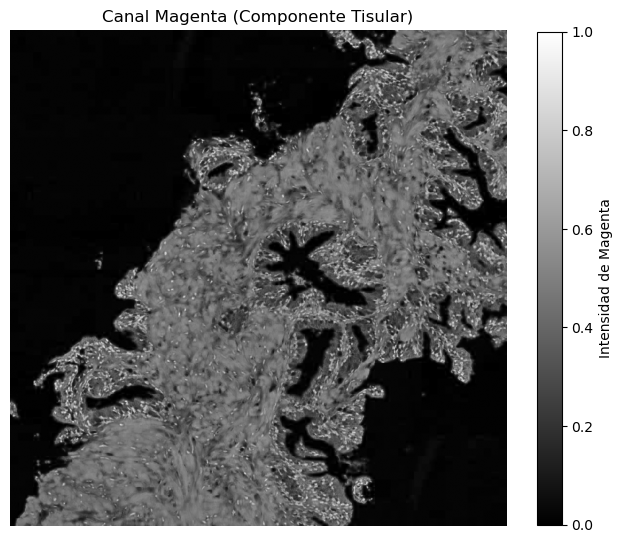

In [12]:
import numpy as np

# 1. Transformación al espacio CMYK (extrayendo solo lo necesario para el Magenta)
# Extraemos el canal Verde (G) de nuestra imagen normalizada
G = img_norm[:, :, 1]

# Calculamos el canal K (Key/Black)
# K es 1 menos el valor máximo de los 3 canales (R, G, B) a lo largo del eje del color (axis=2)
K = 1 - np.max(img_norm, axis=2)

# Inicializamos el canal Magenta (M) con ceros (del mismo tamaño que K)
M = np.zeros_like(K)

# 2. Extraer la componente magenta
# Creamos una máscara booleana para evitar dividir por cero (donde K es exactamente 1)
mask = K < 1

# Aplicamos la fórmula del Magenta solo donde K es menor a 1
M[mask] = (1 - G[mask] - K[mask]) / (1 - K[mask])

# 3. Visualizar la imagen del canal magenta
plt.figure(figsize=(8, 8))
# Usamos cmap='gray' para ver la intensidad. 
# Las zonas más blancas representan una mayor concentración de Magenta (tejido).
# Las zonas negras son ausencia de Magenta (fondo y lúmenes).
plt.imshow(M, cmap='gray')
plt.title("Canal Magenta (Componente Tisular)")
plt.colorbar(shrink=0.8, label="Intensidad de Magenta")
plt.axis('off')
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

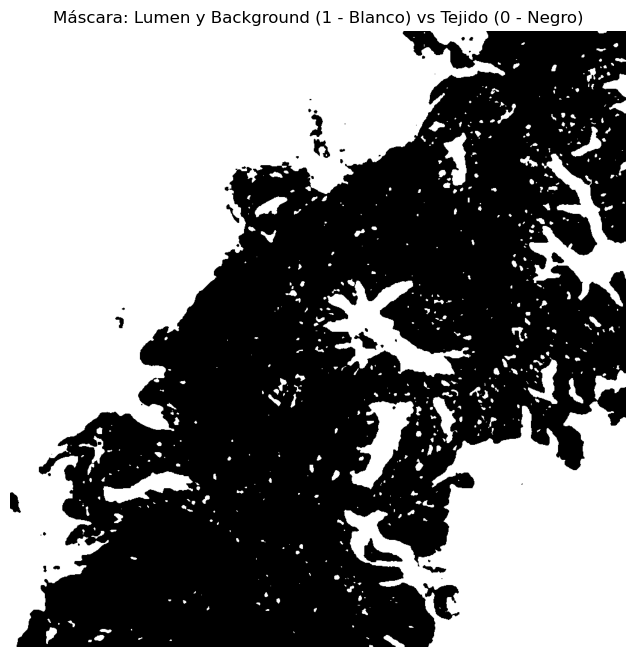

In [13]:
import numpy as np
import cv2 # Asegúrate de tener OpenCV instalado, es el estándar para filtros con tamaños exactos
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

# 1. Convertir la imagen del canal Magenta a formato "uint8" (rango [0-255])
# Multiplicamos por 255 y forzamos el tipo de dato a uint8
M_uint8 = np.uint8(M * 255)

# 2. Aplicar un filtro gaussiano de tamaño 5x5
# cv2.GaussianBlur recibe la imagen, el tamaño del kernel (5, 5) y la desviación estándar (0 deja que la calcule en base al kernel)
M_blur = cv2.GaussianBlur(M_uint8, (5, 5), 0)

# 3. Calcular el umbral usando el método de Otsu
# Otsu encuentra matemáticamente el punto perfecto para separar los píxeles claros de los oscuros
umbral = threshold_otsu(M_blur)

# 4. Crear la máscara binaria
# Recuerda: En nuestro canal Magenta, el tejido es "blanco" (valores altos) 
# y los lúmenes/fondo son "negros" (valores bajos).
# El ingeniero pide que lumen y background sean 1s, y el tejido 0.
# Por lo tanto, todo lo que sea MENOR al umbral será 1, y lo MAYOR o IGUAL será 0.
mascara_fondo_lumen = (M_blur < umbral).astype(np.uint8)

# 5. Visualizar la máscara resultante
plt.figure(figsize=(8, 8))
plt.imshow(mascara_fondo_lumen, cmap='gray')
plt.title("Máscara: Lumen y Background (1 - Blanco) vs Tejido (0 - Negro)")
plt.axis('off')
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

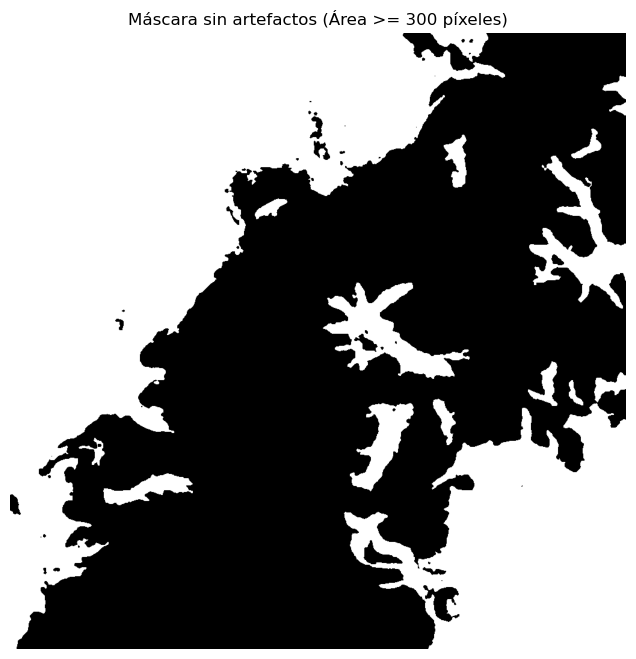

In [14]:
from skimage import morphology
import matplotlib.pyplot as plt
import numpy as np

# 1. Convertir la máscara anterior a formato booleano
# Lo que era 1 pasa a ser True (blanco) y lo que era 0 pasa a ser False (negro)
mascara_bool = mascara_fondo_lumen.astype(bool)

# 2. Eliminar objetos pequeños (artefactos)
# Le decimos que cualquier mancha blanca con área menor a 300 píxeles, la borre (la vuelva negra)
mascara_limpia_bool = morphology.remove_small_objects(mascara_bool, min_size=300)

# (Opcional pero recomendable) Volvemos a convertirla a 0s y 1s para seguir trabajando con números
mascara_limpia = mascara_limpia_bool.astype(np.uint8)

# 3. Visualizar la máscara resultante
plt.figure(figsize=(8, 8))
plt.imshow(mascara_limpia, cmap='gray')
plt.title("Máscara sin artefactos (Área >= 300 píxeles)")
plt.axis('off')
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

Semillas encontradas en zonas separadas: [(0, 0), (1023, 1023)]


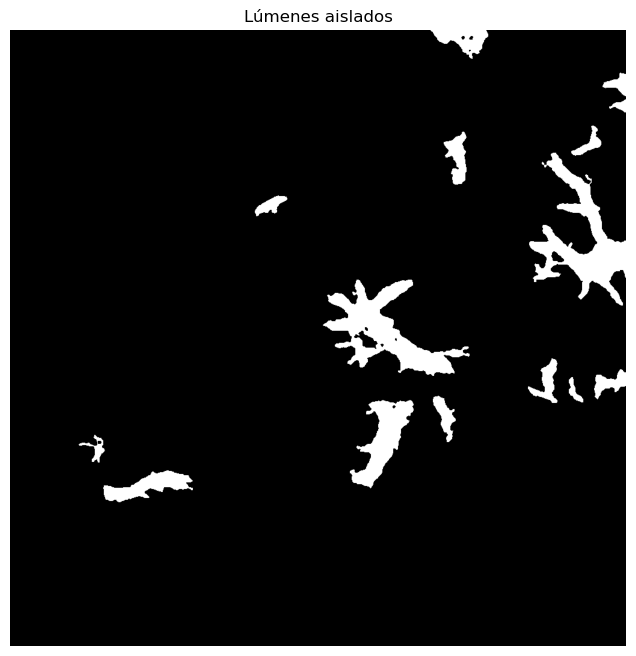

In [15]:
from skimage.segmentation import flood_fill
import matplotlib.pyplot as plt
import numpy as np

# --- NUEVA FUNCIÓN INTELIGENTE PARA SEMILLAS ---
def encontrar_semillas_separadas(mascara, num_semillas=2):
    semillas = []
    filas, columnas = mascara.shape
    # Usamos una máscara temporal para llevar el registro de qué zonas ya encontramos
    mascara_temp = mascara.copy() 
    
    # Revisamos las 4 esquinas estratégicamente (Arriba-Izq, Abajo-Der, Arriba-Der, Abajo-Izq)
    esquinas = [(0, 0), (filas-1, columnas-1), (0, columnas-1), (filas-1, 0)]
    
    for f, c in esquinas:
        if mascara_temp[f, c] == 1: # Si es blanco (fondo)
            semillas.append((f, c))
            # Rellenamos esta zona de negro en la temporal para no volver a agarrar otra semilla aquí
            mascara_temp = flood_fill(mascara_temp, seed_point=(f, c), new_value=0)
            
        if len(semillas) == num_semillas:
            break
            
    return semillas

# 1. Encontrar las semillas automáticamente con la nueva lógica
semillas_fondo = encontrar_semillas_separadas(mascara_limpia, num_semillas=2)
print(f"Semillas encontradas en zonas separadas: {semillas_fondo}")

# 2. Aplicar el algoritmo de expansión (flood_fill) a la máscara real
mascara_lumenes = mascara_limpia.copy() 
for semilla in semillas_fondo:
    mascara_lumenes = flood_fill(mascara_lumenes, seed_point=semilla, new_value=0)

# 3. Visualizar la máscara resultante
plt.figure(figsize=(8, 8))
plt.imshow(mascara_lumenes, cmap='gray')
plt.title("Lúmenes aislados")
plt.axis('off')
plt.show()

#### 5) Rellenar los objetos de los lúmenes

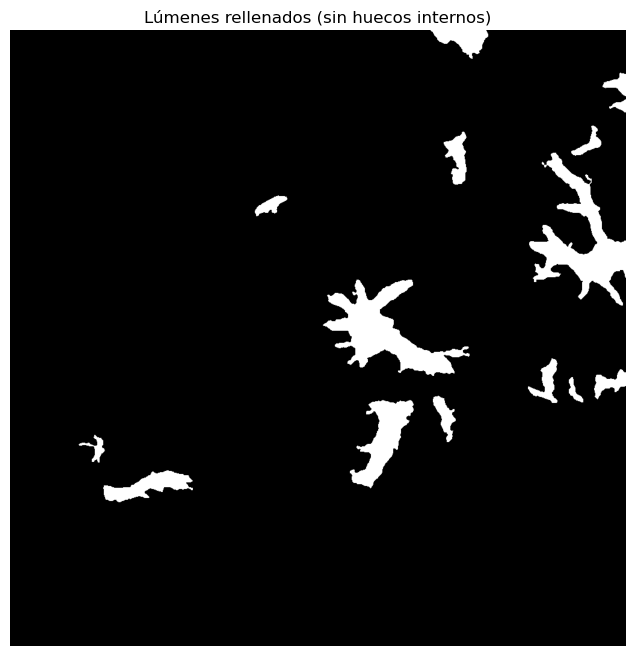

In [16]:
import scipy.ndimage as ndi
import matplotlib.pyplot as plt

# 1. Rellenar los huecos dentro de los lúmenes
# La función buscará cualquier área negra que esté completamente rodeada de blanco
# y la pintará de blanco.
mascara_rellena = ndi.binary_fill_holes(mascara_lumenes)

# 2. Visualizar la máscara resultante
plt.figure(figsize=(8, 8))
plt.imshow(mascara_rellena, cmap='gray')
plt.title("Lúmenes rellenados (sin huecos internos)")
plt.axis('off')
plt.show()

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

Número de lúmenes detectados: 15


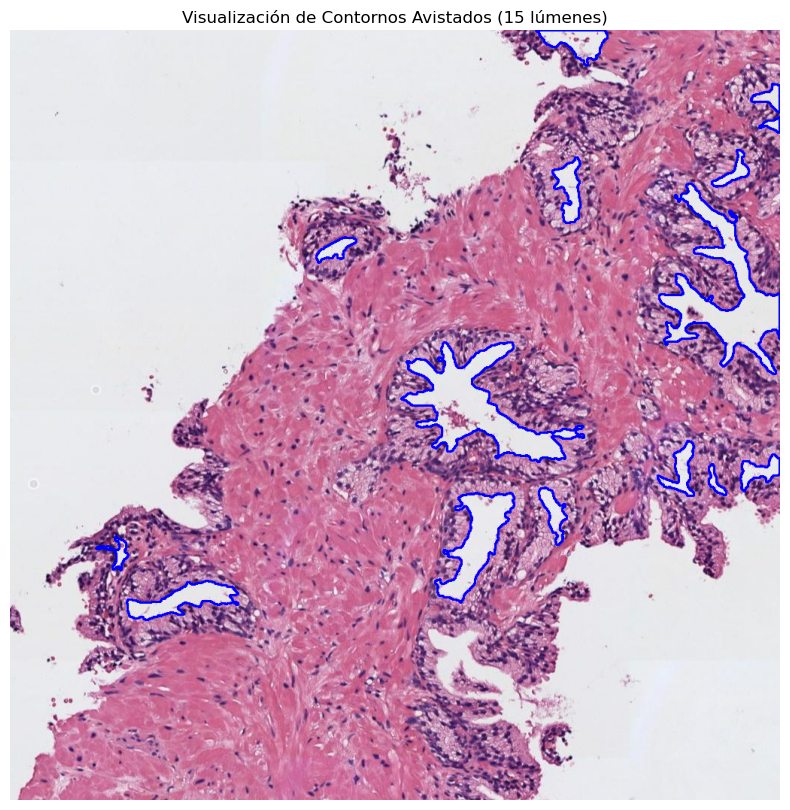

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Asegurarnos de tener la imagen original en formato uint8 (0-255) para dibujar sobre ella.
# Si img_norm es float [0,1], la convertimos de vuelta. Si 'img' ya existía del paso 0, úsala.
# Asumiremos que tenemos img_norm del paso 0.
if img_norm.dtype != np.uint8:
    image_base = (img_norm * 255).astype(np.uint8)
else:
    image_base = img_norm.copy()

# 2. Convertir la máscara booleana (True/False) a uint8 (0 / 255)
# cv2.findContours necesita estrictamente una imagen de 8 bits donde 255 es blanco.
mask_to_draw = (mascara_rellena * 255).astype(np.uint8)

# 3. Detectar los contornos
# cv2.RETR_EXTERNAL: solo busca contornos externos (ideal, ya rellenamos huecos internos)
# cv2.CHAIN_APPROX_SIMPLE: comprime los segmentos para ahorrar memoria
cnts, _ = cv2.findContours(mask_to_draw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Número de lúmenes detectados: {len(cnts)}")

# 4. Dibujar los contornos sobre la imagen original RGB
color_azul = (0, 0, 255) #  Azul en formato RGB
grosor_linea = 2          # Para que sea perfectamente visible

# cv2.drawContours(imagen_destino, lista_contornos, indice_contorno (-1 todos), color, grosor)
img_overlay = image_base.copy()
cv2.drawContours(img_overlay, cnts, -1, color_azul, grosor_linea)

# 5. Visualizar la imagen superpuesta
plt.figure(figsize=(10, 10))
plt.imshow(img_overlay)
plt.title(f"Visualización de Contornos Avistados ({len(cnts)} lúmenes)")
plt.axis('off')
plt.show()

#### 7) Identificar y cropear el lumen más grande

Número de lúmenes estudiados: 15
Índice del lumen más grande: 7
Área del lumen más grande (en píxeles cuadrados): 13369.00
Coordenadas del Crop: (x=520, y=415), Ancho=244, Alto=160


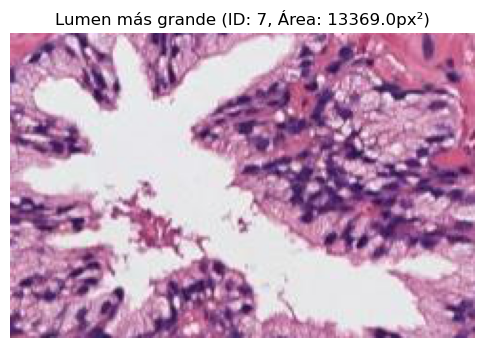

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Asumimos que venimos con la lista de contornos 'cnts' del paso anterior
# y la imagen original 'img' (o 'img_overlay' para referencia, pero mejor la original 'img')

if len(cnts) > 0:
    # 1. Determinar cuál es el lumen de mayor área
    # Usamos una "list comprehension" para calcular el área de cada contorno en 'cnts'
    areas = [cv2.contourArea(c) for c in cnts]
    
    # Encontramos el índice del área máxima
    indice_max = np.argmax(areas)
    area_max = areas[indice_max]
    
    print(f"Número de lúmenes estudiados: {len(areas)}")
    print(f"Índice del lumen más grande: {indice_max}")
    print(f"Área del lumen más grande (en píxeles cuadrados): {area_max:.2f}")
    
    largest_contour = cnts[indice_max]
    
    # 2. Hacer un crop del mismo sobre la imagen original RGB
    # Primero obtenemos el "Bounding Box" (caja delimitadora) del contorno más grande
    # x,y son coordenadas superiores izquierdas; w,h son ancho y alto
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    print(f"Coordenadas del Crop: (x={x}, y={y}), Ancho={w}, Alto={h}")
    
    # Realizamos el crop (recorte) usando NumPy slicing sobre la imagen base
    # IMPORTANTE: En NumPy las coordenadas son [fila_inicial:fila_final, col_inicial:col_final]
    # lo cual corresponde a [y:y+h, x:x+w]
    lumen_cropeado = image_base[y:y+h, x:x+w, :]
    
    # 3. Visualizar el lumen cropeado
    plt.figure(figsize=(6, 6))
    plt.imshow(lumen_cropeado)
    plt.title(f"Lumen más grande (ID: {indice_max}, Área: {area_max:.1f}px²)")
    plt.axis('off')
    plt.show()
    
else:
    print("Error: No hay lúmenes en pasos de antes.")

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [19]:
import math
import numpy as np
import cv2
from skimage.measure import regionprops

# 1. Crear una máscara binaria aislada solo para este lumen cropeado
# Usamos las variables h, w, x, y, y largest_contour del paso 7
mask_lumen_crop = np.zeros((h, w), dtype=np.uint8)

# Desplazamos los puntos del contorno para que coincidan con el origen (0,0) del recorte
contorno_desplazado = largest_contour - [x, y]
cv2.drawContours(mask_lumen_crop, [contorno_desplazado], -1, 1, cv2.FILLED)

# 2. Extraer las propiedades con scikit-image
# regionprops analiza las regiones etiquetadas (valores > 0)
propiedades = regionprops(mask_lumen_crop)[0]

# 3. Asignar las características a variables manejando la compatibilidad de versiones de skimage
area = propiedades.area
bbox_area = propiedades.bbox_area
convex_area = propiedades.convex_area
eccentricity = propiedades.eccentricity
# Para algunas versiones antiguas los nombres de los atributos cambian, usamos getattr por seguridad
equivalent_diameter = getattr(propiedades, 'equivalent_diameter_area', getattr(propiedades, 'equivalent_diameter', 0))
extent = propiedades.extent
feret_diameter = getattr(propiedades, 'feret_diameter_max', 0)
major_axis = getattr(propiedades, 'axis_major_length', getattr(propiedades, 'major_axis_length', 0))
minor_axis = getattr(propiedades, 'axis_minor_length', getattr(propiedades, 'minor_axis_length', 0))
orientation = propiedades.orientation
perimeter = propiedades.perimeter
solidity = propiedades.solidity

# Calcular la Compacidad matemáticamente
if perimeter > 0:
    compactness = (4 * math.pi * area) / (perimeter ** 2)
else:
    compactness = 0.0

# 4. Imprimir resultados redondeados al cuarto decimal usando f-strings
print("--- CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN ---")
print(f"1) Área: {area:.4f}")
print(f"2) Área de la bounding box: {bbox_area:.4f}")
print(f"3) Área convexa: {convex_area:.4f}")
print(f"4) Excentricidad: {eccentricity:.4f}")
print(f"5) Diámetro equivalente: {equivalent_diameter:.4f}")
print(f"6) Extensión: {extent:.4f}")
print(f"7) Diámetro Feret: {feret_diameter:.4f}")
print(f"8) Longitud del eje mayor: {major_axis:.4f}")
print(f"9) Longitud del eje menor: {minor_axis:.4f}")
print(f"10) Orientación: {orientation:.4f}")
print(f"11) Perímetro: {perimeter:.4f}")
print(f"12) Solidez: {solidity:.4f}")
print(f"13) Compacidad: {compactness:.4f}")

--- CARACTERÍSTICAS GEOMÉTRICAS DEL LUMEN ---
1) Área: 13884.0000
2) Área de la bounding box: 39040.0000
3) Área convexa: 28836.0000
4) Excentricidad: 0.8466
5) Diámetro equivalente: 132.9574
6) Extensión: 0.3556
7) Diámetro Feret: 257.2334
8) Longitud del eje mayor: 236.6036
9) Longitud del eje menor: 125.9393
10) Orientación: 1.0140
11) Perímetro: 1200.7981
12) Solidez: 0.4815
13) Compacidad: 0.1210


https://github.com/alexis77710/machine-learning-introduccion.git